# Reward scoring demo - Robometer on nvidia/LIBERO_LeRobot_v3

This demo scores robot episodes with a reward model ([Robometer-4B](https://huggingface.co/robometer/Robometer-4B)) as a Daft pipeline: per-frame task progress (0-1) plus success probability, written back as a dataset column with `score_rewards`. Downstream uses: filter failed or stalled episodes before BC training, dense reward for RL post-training, and catching mislabeled tasks (all-zero progress usually means the task text is wrong).

Scoring is a pure HTTP call - you bring a running Robometer eval server (`run_robometer_server.py` on any NVIDIA GPU, or `modal deploy modal_eval_server.py`; both were generated next to this demo) and point `ROBOMETER_URL` at it.

## Setup

Install with `pip install daft-physical-ai huggingface_hub matplotlib`, then import.

In [1]:
import daft
from daft import col, lit

from daft_physical_ai.rewards import score_rewards

## Configure

The dataset, which camera's video to decode, how many episodes to score, and how many frames to sample per episode.

In [2]:
DATASET = "nvidia/LIBERO_LeRobot_v3"
SPLIT = "libero_90"
VIDEO_KEY = "observation.images.image"  # camera whose video the episodes index into
EPISODES = 5
MAX_FRAMES = 8  # frames sampled per episode (first + last always included)

## Point at your Robometer server

The pipeline takes a URL and doesn't care what's behind it - a local GPU, Modal, or anything else that serves the eval server's `/evaluate_batch_npy`.

In [3]:
import os

# Any running Robometer eval server works here - the pipeline only sees a URL.
#   local GPU:  python run_robometer_server.py         (then http://localhost:8001)
#   Modal:      modal deploy modal_eval_server.py      (prints the https URL)
ROBOMETER_URL = os.environ["ROBOMETER_URL"]
# Modal proxy-auth deployments need these two headers; a local server needs none.
HEADERS = (
    {"Modal-Key": os.environ["MODAL_KEY"], "Modal-Secret": os.environ["MODAL_SECRET"]}
    if os.environ.get("MODAL_KEY")
    else None
)

## Fetch the episode metadata and video

LeRobot v3 stores episode metadata as parquet and concatenates episodes into shared mp4 files. The first metadata and video files cover the first episodes, which is all this demo scores.

In [4]:
from huggingface_hub import hf_hub_download

meta_path = hf_hub_download(DATASET, f"{SPLIT}/meta/episodes/chunk-000/file-000.parquet", repo_type="dataset")
video_path = hf_hub_download(DATASET, f"{SPLIT}/videos/{VIDEO_KEY}/chunk-000/file-000.mp4", repo_type="dataset")

## Build the episode DataFrame

One row per episode: the task text (from the episode's own LeRobot metadata - nothing hand-written), its length, and where its frames live in the video.

In [5]:
df = (
    daft.read_parquet(meta_path)
    .sort("episode_index")
    .limit(EPISODES)
    .select(
        "episode_index",
        col("tasks").list_join("; ").alias("task"),
        "length",
        col(f"videos/{VIDEO_KEY}/from_timestamp").alias("from_ts"),
        col(f"videos/{VIDEO_KEY}/to_timestamp").alias("to_ts"),
        lit(video_path).alias("video_path"),
    )
)

## Score the episodes

`score_rewards` returns a reward column: it samples `MAX_FRAMES` frames per episode, decodes them from the episode's segment of the video, and asks the server for per-frame progress + success. It's a lazy async Daft UDF, so nothing runs until we materialize below - and episodes score concurrently when they do.

In [6]:
df = df.with_column(
    "rewards",
    score_rewards(
        df["task"], df["length"], df["from_ts"], df["to_ts"], df["video_path"],
        url=ROBOMETER_URL, max_frames=MAX_FRAMES, headers=HEADERS,
    ),
)

## Read the curves

A healthy episode climbs toward 1.0. A curve that flatlines near 0 is a failed or stalled episode - or a mislabeled task - that you almost trained on.

In [7]:
episodes = df.to_pylist()
for e in episodes:
    r = e["rewards"]
    print(f"ep{e['episode_index']} ({e['task']}):")
    print(f"  progress = {[round(p, 2) for p in r['reward_score']]}")
    print(f"  success  = {r['robometer_success'][-1]:.2f} (final frame)")

ep0 (open the bottom drawer of the cabinet):
  progress = [0.1, 0.22, 0.3, 0.4, 0.59, 0.7, 0.83, 0.92]
  success  = 0.97 (final frame)
ep1 (put the white bowl on top of the cabinet):
  progress = [0.14, 0.21, 0.21, 0.27, 0.26, 0.16, 0.21, 0.77]
  success  = 0.49 (final frame)
ep2 (pick up the alphabet soup and put it in the tray):
  progress = [0.03, 0.02, 0.05, 0.26, 0.46, 0.52, 0.82, 0.93]
  success  = 0.93 (final frame)
ep3 (put the chocolate pudding to the right of the plate):
  progress = [0.07, 0.16, 0.23, 0.36, 0.47, 0.61, 0.68, 0.66]
  success  = 0.16 (final frame)
ep4 (put the black bowl on top of the cabinet):
  progress = [0.07, 0.19, 0.31, 0.43, 0.56, 0.71, 0.83, 0.9]
  success  = 0.88 (final frame)


## Plot the progress curves

Needs `matplotlib`.

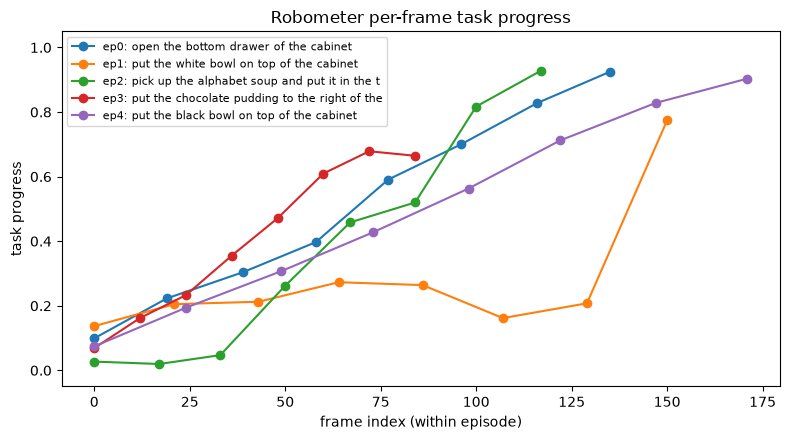

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4.5))
for e in episodes:
    r = e["rewards"]
    xs = [f["index"] for f in r["reward_frames"]]
    ax.plot(xs, r["reward_score"], marker="o", label=f"ep{e['episode_index']}: {e['task'][:45]}")
ax.set_xlabel("frame index (within episode)")
ax.set_ylabel("task progress")
ax.set_ylim(-0.05, 1.05)
ax.set_title("Robometer per-frame task progress")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

## Filter with a Daft query

The scores are ordinary columns, so quality gates are one-liners - here, episodes whose final-frame success probability is below 0.5.

In [9]:
from daft import col

# episodes the model doubts succeeded - review these before training on them
flagged = df.where(col("rewards")["robometer_success"][-1] < 0.5)
flagged.select("episode_index", "task").show()

episode_indexInt64,taskString
1,put the white bowl on top of the cabinet
3,put the chocolate pudding to the right of the plate
